# Day 6 — Mobile App Usage & Screen Time EDA

Датасет: `mobile_app_usage_screen_time.csv` — 10 000 записей, 34 признака.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/mobile_app_usage_screen_time.csv")
df.head()

,record_id,year,month,quarter,day_of_week,country,age_group,gender,device_brand,operating_system,...,app_rating_given,review_submitted,primary_usage_time,dark_mode_preference,location_permission,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used,app_deleted_and_reinstalled
0,APP0000001,2024,11,Q4,Thursday,Turkey,45-54,Male,Xiaomi,Android,...,4,No,Lunch (12-2pm),Sometimes,While Using,Moderate,Yes,Positive,Yes,Yes
1,APP0000002,2022,5,Q2,Friday,USA,25-34,Male,Huawei,Android,...,4,Yes,Evening (6-10pm),Sometimes,Never,NaN,Yes,Negative,Yes,Yes
2,APP0000003,2024,9,Q3,Sunday,USA,25-34,Male,Samsung,Android,...,4,Yes,Evening (6-10pm),Sometimes,While Using,NaN,No,Negative,No,Yes
3,APP0000004,2023,7,Q3,Tuesday,Pakistan,25-34,Male,Samsung,Android,...,4,No,Commute (9-11am),Never,Always,Moderate,Somewhat,Negative,Yes,No
4,APP0000005,2023,3,Q1,Tuesday,UAE,25-34,Male,OnePlus,Android,...,1,No,Commute (9-11am),Always,Not Applicable,Moderate,Yes,Neutral,Yes,No


In [18]:
df.describe()

,year,month,daily_screen_time_minutes,session_duration_minutes,sessions_per_day,app_opens_per_day,data_used_mb_per_day,battery_drain_pct_per_session,notifications_received_per_day,monthly_spend_usd,app_rating_given
count,10000.00000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2023.12990,6.553800,85.500640,35.68338,6.02530,8.023700,209.452250,18.481170,25.006400,7.840883,3.907900
std,0.77813,3.434397,70.969522,23.97657,2.43217,2.789537,306.113715,9.545508,5.056057,19.273629,1.057795
min,2022.00000,1.000000,5.700000,2.00000,1.00000,1.000000,6.100000,2.000000,9.000000,0.000000,1.000000
25%,2023.00000,4.000000,35.500000,17.50000,4.00000,6.000000,45.600000,10.200000,21.000000,0.000000,3.000000
50%,2023.00000,7.000000,63.400000,29.90000,6.00000,8.000000,96.150000,18.400000,25.000000,0.000000,4.000000
75%,2024.00000,10.000000,112.700000,48.70000,8.00000,10.000000,241.775000,26.700000,28.000000,7.450000,5.000000
max,2024.00000,12.000000,600.000000,119.90000,15.00000,21.000000,3852.100000,35.000000,49.000000,350.390000,5.000000


In [37]:
print('среднее :', round(df["session_duration_minutes"].mean()))
print('медиана :', round(df["session_duration_minutes"].median()))
print('отношение среднее/медиана:', round(df["session_duration_minutes"].mean()/df["session_duration_minutes"].median(), 2))

среднее : 36
медиана : 30
отношение среднее/медиана: 1.19


In [38]:
print('среднее :', round(df["daily_screen_time_minutes"].mean()))
print('медиана :', round(df["daily_screen_time_minutes"].median()))
print('отношение среднее/медиана:', round(df["daily_screen_time_minutes"].mean()/df["daily_screen_time_minutes"].median(), 2))

среднее : 86
медиана : 63
отношение среднее/медиана: 1.35


## Квартили daily_screen_time_minutes

Q1=35.50  медиана=63.40  Q3=112.70  IQR=77.20


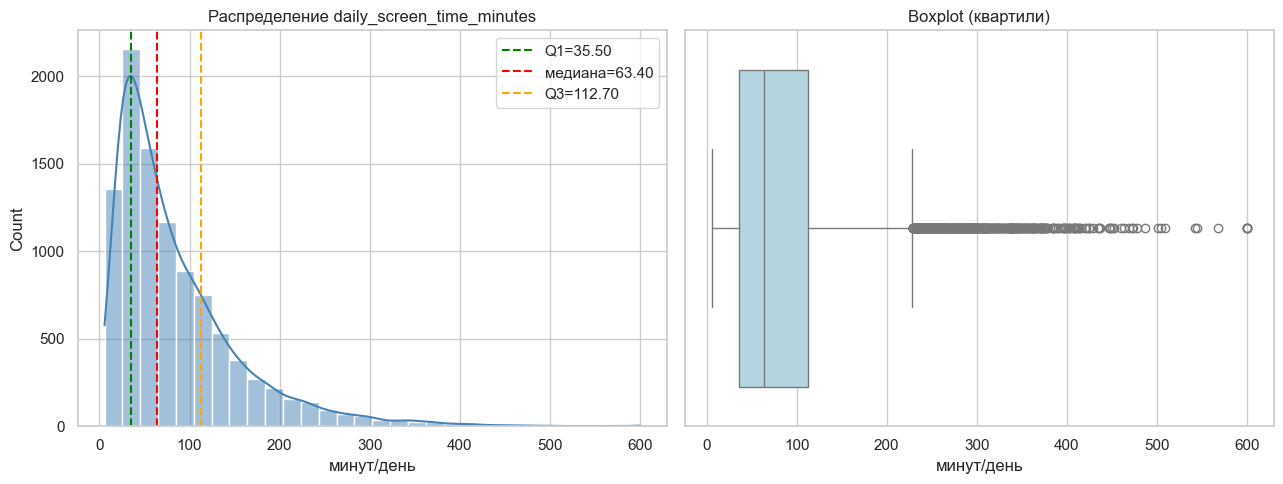

In [40]:
s = df["daily_screen_time_minutes"]
q1, q2, q3 = s.quantile([.25, .5, .75])
print(f"Q1={q1:.2f}  медиана={q2:.2f}  Q3={q3:.2f}  IQR={q3-q1:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(s, bins=30, kde=True, color="steelblue", ax=ax[0])
for q, c, l in [(q1, "green", "Q1"), (q2, "red", "медиана"), (q3, "orange", "Q3")]:
    ax[0].axvline(q, color=c, linestyle="--", label=f"{l}={q:.2f}")
ax[0].set_title("Распределение daily_screen_time_minutes")
ax[0].set_xlabel("минут/день")
ax[0].legend()

sns.boxplot(x=s, color="lightblue", ax=ax[1])
ax[1].set_title("Boxplot (квартили)")
ax[1].set_xlabel("минут/день")
plt.tight_layout()
plt.show()

## Проверка выбросов (IQR) по числовым колонкам

Исключаем служебные/категориальные числа (`year`, `month`, `app_rating_given`).

In [20]:
drop_cols = ["year", "month", "app_rating_given"]
num = df.select_dtypes("number").drop(columns=drop_cols)

for c in num.columns:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f"{c:<32} выбросов: {n:>5}  ({100*n/len(df):.1f}%)")

daily_screen_time_minutes        выбросов:   494  (4.9%)
session_duration_minutes         выбросов:   290  (2.9%)
sessions_per_day                 выбросов:    11  (0.1%)
app_opens_per_day                выбросов:    43  (0.4%)
data_used_mb_per_day             выбросов:   933  (9.3%)
battery_drain_pct_per_session    выбросов:     0  (0.0%)
notifications_received_per_day   выбросов:    61  (0.6%)
monthly_spend_usd                выбросов:  1516  (15.2%)


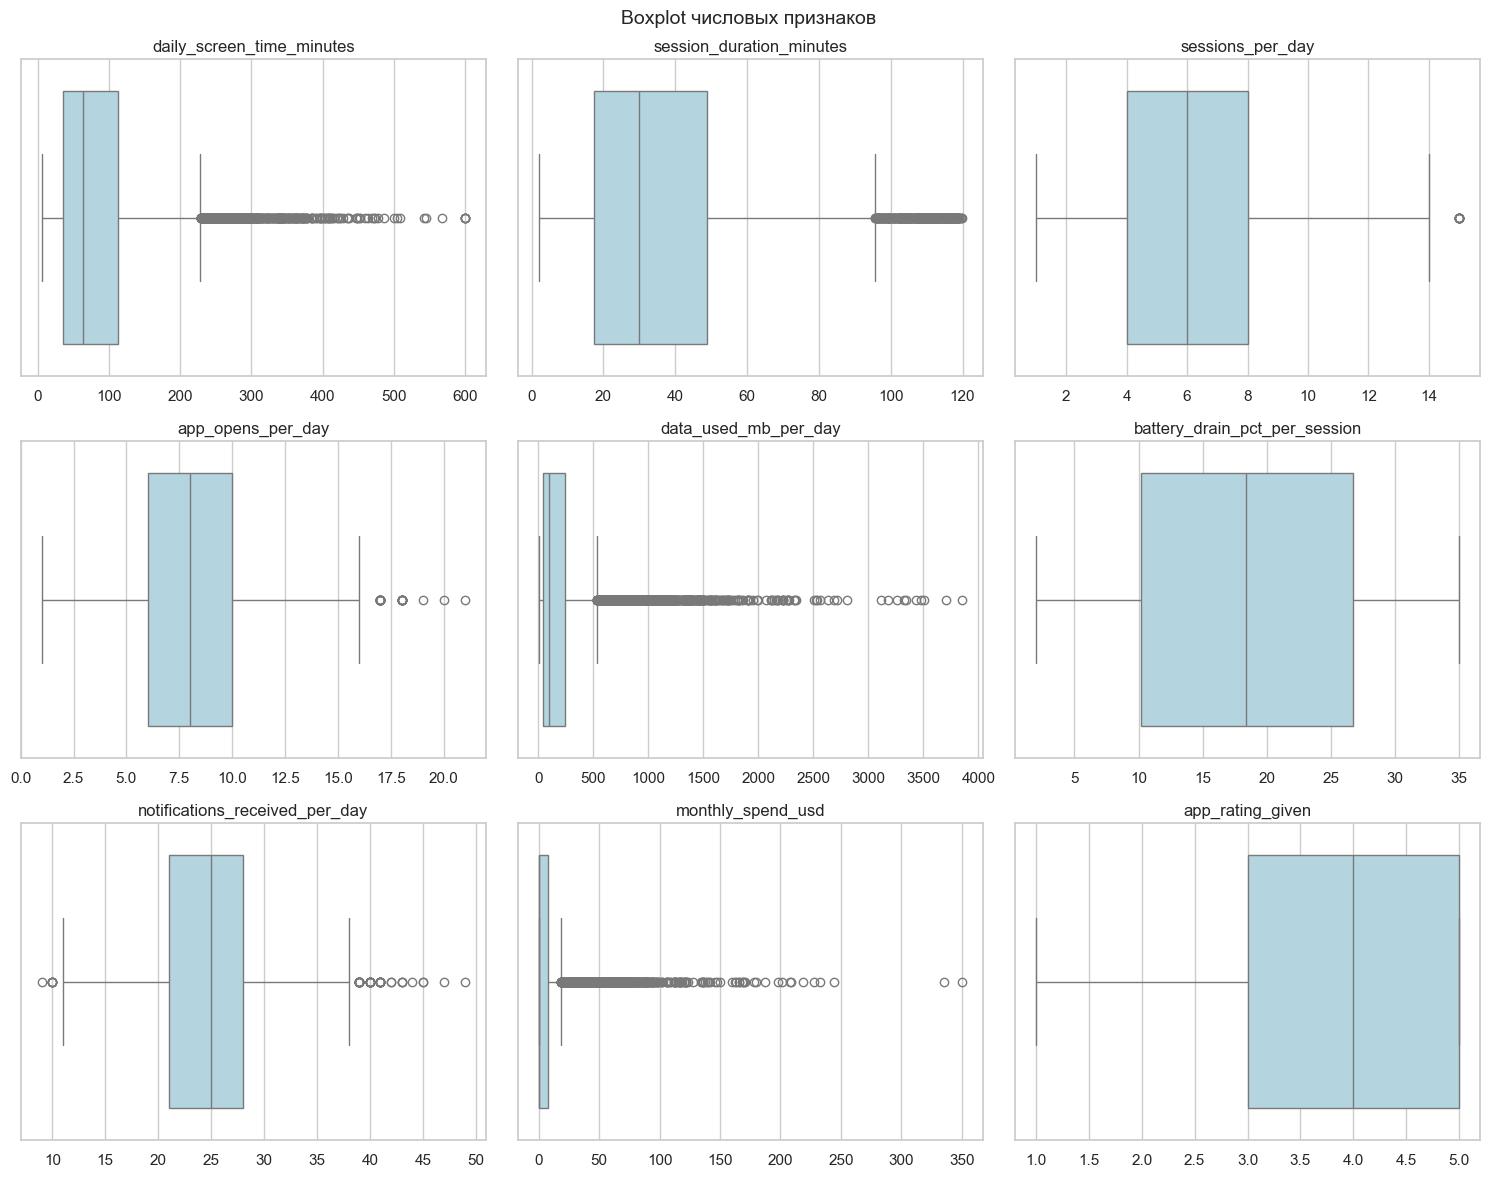

In [41]:
n = len(num.columns)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, 4*rows))
for ax, c in zip(axes.flat, num.columns):
    sns.boxplot(x=df[c], color="lightblue", ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
for ax in axes.flat[n:]:
    ax.set_visible(False)
plt.suptitle("Boxplot числовых признаков", fontsize=14)
plt.tight_layout()
plt.show()

## Связь session_duration_minutes ↔ app_category

Категория + число → используем **корреляционное отношение η** (eta): 0 = нет связи, 1 = полная.
Визуализация — seaborn `violinplot` (распределение) + `barplot` (средние).

eta (корреляционное отношение) = 0.712


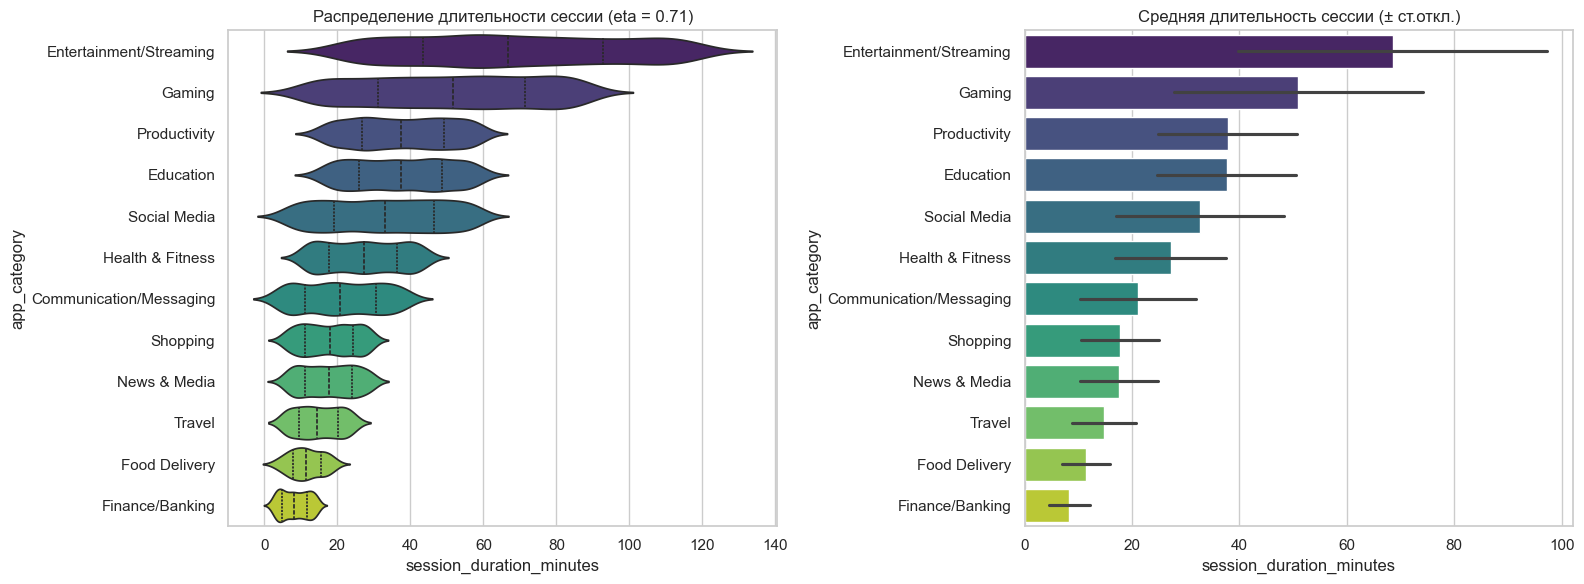

app_category
Entertainment/Streaming    68.6
Gaming                     51.0
Productivity               37.8
Education                  37.7
Social Media               32.7
Health & Fitness           27.2
Communication/Messaging    21.2
Shopping                   17.7
News & Media               17.6
Travel                     14.8
Food Delivery              11.4
Finance/Banking             8.4
Name: session_duration_minutes, dtype: float64

In [22]:
def correlation_ratio(cats, vals):
    means = vals.groupby(cats).mean()
    n = vals.groupby(cats).count()
    grand = vals.mean()
    ss_between = (n * (means - grand) ** 2).sum()
    ss_total = ((vals - grand) ** 2).sum()
    return np.sqrt(ss_between / ss_total)

eta = correlation_ratio(df["app_category"], df["session_duration_minutes"])
print(f"eta (корреляционное отношение) = {eta:.3f}")

order = (df.groupby("app_category")["session_duration_minutes"]
         .mean().sort_values(ascending=False).index)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.violinplot(data=df, y="app_category", x="session_duration_minutes",
               order=order, hue="app_category", hue_order=order, legend=False,
               palette="viridis", inner="quartile", ax=ax[0])
ax[0].set_title(f"Распределение длительности сессии (eta = {eta:.2f})")

sns.barplot(data=df, y="app_category", x="session_duration_minutes",
            order=order, hue="app_category", hue_order=order, legend=False,
            palette="viridis", errorbar="sd", ax=ax[1])
ax[1].set_title("Средняя длительность сессии (± ст.откл.)")
plt.tight_layout()
plt.show()

df.groupby("app_category")["session_duration_minutes"].mean().round(1).sort_values(ascending=False)

In [33]:
r = df['sessions_per_day'].corr(df['monthly_spend_usd'])
print('корреляция monthly_spend_usd и app_opens_per_day по всем данным: r =', round(r, 2))


корреляция monthly_spend_usd и app_opens_per_day по всем данным: r = 0.01


In [42]:
df.describe(include="all")

,record_id,year,month,quarter,day_of_week,country,age_group,gender,device_brand,operating_system,...,app_rating_given,review_submitted,primary_usage_time,dark_mode_preference,location_permission,sleep_disruption_from_phone,screen_time_concern,mental_health_impact,digital_wellbeing_feature_used,app_deleted_and_reinstalled
count,10000,10000.00000,10000.000000,10000,10000,10000,10000,10000,10000,10000,...,10000.000000,10000,10000,10000,10000,7233,10000,10000,10000,10000
unique,10000,NaN,NaN,4,7,15,7,3,10,2,...,NaN,2,6,3,4,3,3,5,2,2
top,APP0000001,NaN,NaN,Q4,Saturday,USA,25-34,Male,Apple,Android,...,NaN,No,Evening (6-10pm),Always,While Using,Mild,Yes,Neutral,No,No
freq,1,NaN,NaN,2556,1635,1257,2795,4875,2847,7153,...,NaN,7102,3227,4215,3775,3439,3753,3457,6455,6801
mean,NaN,2023.12990,6.553800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.907900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.77813,3.434397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.057795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2022.00000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2023.00000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2023.00000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2024.00000,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Матрица корреляций числовых признаков

Pearson по всем числовым колонкам (без `year`/`month`). Показывает линейные связи.

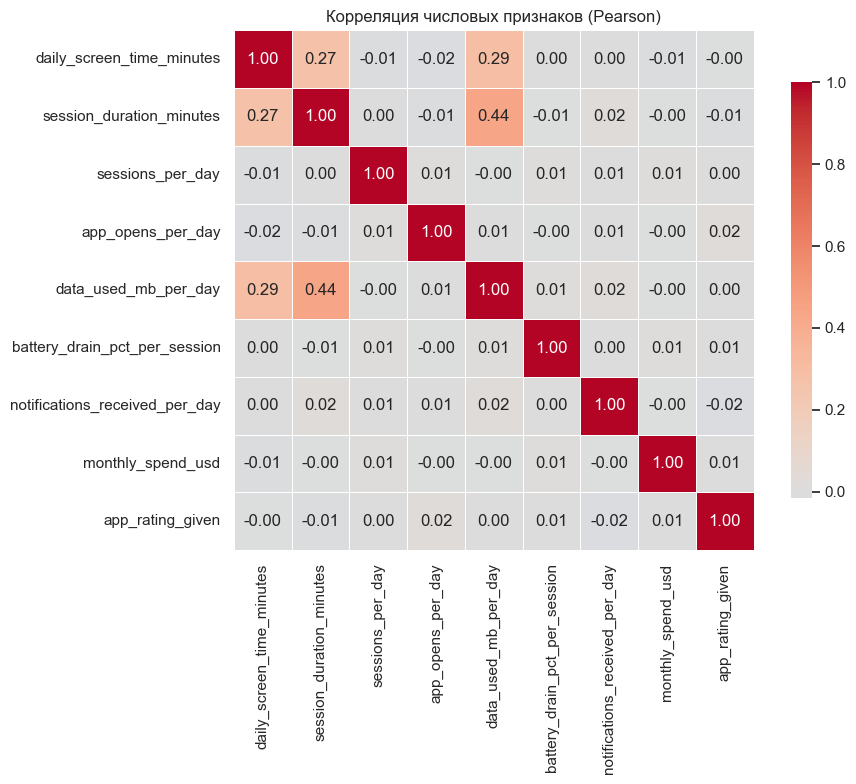

session_duration_minutes        data_used_mb_per_day              0.44
daily_screen_time_minutes       data_used_mb_per_day              0.29
                                session_duration_minutes          0.27
data_used_mb_per_day            notifications_received_per_day    0.02
app_opens_per_day               app_rating_given                  0.02
session_duration_minutes        notifications_received_per_day    0.02
notifications_received_per_day  app_rating_given                 -0.02
daily_screen_time_minutes       app_opens_per_day                -0.02
dtype: float64

In [34]:
num = df.select_dtypes("number").drop(columns=["year", "month"])
corr = num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Корреляция числовых признаков (Pearson)")
plt.tight_layout()
plt.show()

# Топ пар по силе связи
corr_pairs = (corr.where(~np.eye(len(corr), dtype=bool)).stack()
              .drop_duplicates().sort_values(key=abs, ascending=False))
corr_pairs.head(8).round(2)

## Связь с нарушением сна (sleep_disruption_from_phone)

Колонка категориальная (Mild / Moderate / Severe, ~2767 пропусков) → снова η.

eta (нарушение сна ↔ метрика):
  0.026  battery_drain_pct_per_session
  0.026  monthly_spend_usd
  0.024  session_duration_minutes
  0.023  data_used_mb_per_day
  0.019  daily_screen_time_minutes
  0.018  notifications_received_per_day
  0.012  sessions_per_day
  0.008  app_rating_given
  0.003  app_opens_per_day


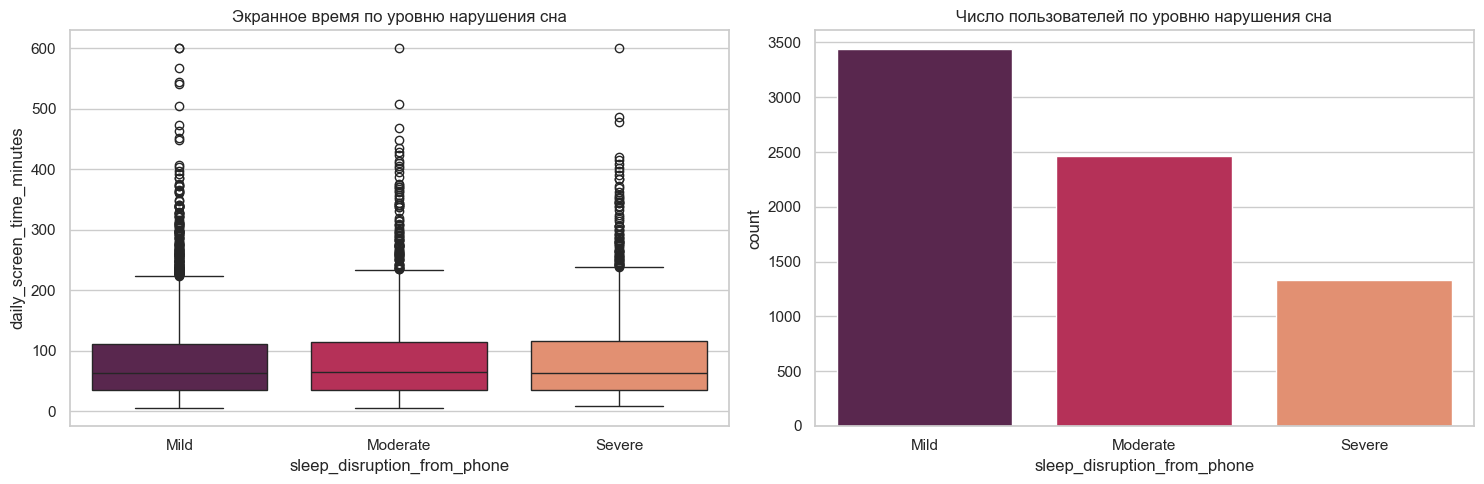

In [35]:
sleep_col = "sleep_disruption_from_phone"
order_s = ["Mild", "Moderate", "Severe"]

# eta: связь нарушения сна с числовыми метриками (NaN в категории отбрасываем)
def eta_ratio(cat_name, val_name):
    m = df.dropna(subset=[cat_name])
    c, v = m[cat_name], m[val_name]
    means, n, grand = v.groupby(c).mean(), v.groupby(c).count(), v.mean()
    return np.sqrt((n * (means - grand) ** 2).sum() / ((v - grand) ** 2).sum())

num = df.select_dtypes("number").drop(columns=["year", "month"])
etas = {c: eta_ratio(sleep_col, c) for c in num.columns}
print("eta (нарушение сна ↔ метрика):")
for c, e in sorted(etas.items(), key=lambda x: -x[1]):
    print(f"  {e:.3f}  {c}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x=sleep_col, y="daily_screen_time_minutes", order=order_s,
            hue=sleep_col, hue_order=order_s, legend=False, palette="rocket", ax=ax[0])
ax[0].set_title("Экранное время по уровню нарушения сна")
sns.countplot(data=df, x=sleep_col, order=order_s,
              hue=sleep_col, hue_order=order_s, legend=False, palette="rocket", ax=ax[1])
ax[1].set_title("Число пользователей по уровню нарушения сна")
plt.tight_layout()
plt.show()

## Матрица зависимости (все типы признаков)

Единая мера связи 0–1 для смешанных данных:
- **число ↔ число** — |Pearson|
- **категория ↔ категория** — Cramér's V (с поправкой)
- **число ↔ категория** — корреляционное отношение η

In [ ]:
from scipy.stats import chi2_contingency

cat = ["app_category", "subscription_type", "operating_system", "gender", "age_group",
       "in_app_purchase", "primary_usage_time", "dark_mode_preference",
       "sleep_disruption_from_phone", "screen_time_concern", "mental_health_impact",
       "digital_wellbeing_feature_used", "notification_settings"]
num = ["daily_screen_time_minutes", "session_duration_minutes", "sessions_per_day",
       "app_opens_per_day", "data_used_mb_per_day", "battery_drain_pct_per_session",
       "notifications_received_per_day", "monthly_spend_usd", "app_rating_given"]
cols = num + cat

# категория <-> категория (0..1) с поправкой на смещение
def cramers_v(a, b):
    t = pd.crosstab(a, b)
    chi2 = chi2_contingency(t)[0]
    n = t.sum().sum(); r, k = t.shape
    phi2c = max(0, chi2/n - (k-1)*(r-1)/(n-1))
    rc = r - (r-1)**2/(n-1); kc = k - (k-1)**2/(n-1)
    return np.sqrt(phi2c / max(min(kc-1, rc-1), 1e-9))

# число <-> категория: корреляционное отношение eta (0..1)
def eta_mixed(cat_s, num_s):
    m = pd.concat([cat_s, num_s], axis=1).dropna()
    c, v = m.iloc[:, 0], m.iloc[:, 1]
    means, n_, g = v.groupby(c).mean(), v.groupby(c).count(), v.mean()
    return np.sqrt((n_*(means-g)**2).sum() / ((v-g)**2).sum())

M = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        a, b = cols[i], cols[j]
        if a in num and b in num:
            val = abs(df[a].corr(df[b]))
        elif a in cat and b in cat:
            val = cramers_v(df[a], df[b])
        else:
            cs, ns = (a, b) if a in cat else (b, a)
            val = eta_mixed(df[cs], df[ns])
        M.iloc[i, j] = M.iloc[j, i] = val

plt.figure(figsize=(15, 13))
sns.heatmap(M, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .7}, annot_kws={"size": 7})
plt.title("Матрица зависимости (Pearson | Cramer's V | eta), шкала 0-1", fontsize=15)
plt.tight_layout()
plt.show()

# Топ-10 самых сильных зависимостей
pairs = (M.where(~np.eye(len(M), dtype=bool)).stack()
         .drop_duplicates().sort_values(ascending=False))
pairs.head(10).round(3)

## Распределение app_category

Сколько записей в каждой категории приложений (countplot, отсортировано по частоте).

In [ ]:
order_c = df["app_category"].value_counts().index

plt.figure(figsize=(11, 6))
ax = sns.countplot(data=df, y="app_category", order=order_c,
                   hue="app_category", legend=False, palette="viridis")
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
plt.title("Распределение app_category")
plt.xlabel("Количество записей")
plt.ylabel("")
plt.tight_layout()
plt.show()

df["app_category"].value_counts()